In [3]:
# Step 1 - Import Libraries
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# Step 2 - Load the Data
train_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset/train",
    image_size=(64, 64),
    batch_size=32
)

Found 2301 files belonging to 10 classes.


In [5]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset/test",
    image_size=(64, 64),
    batch_size=32
)

Found 1025 files belonging to 10 classes.


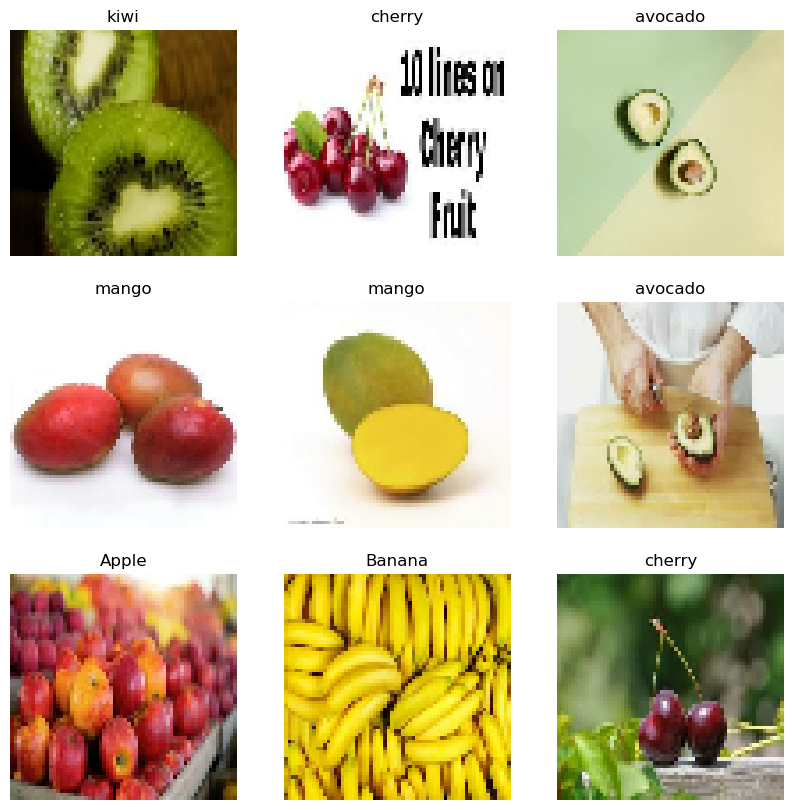

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(train_ds.class_names[labels[i]])
        plt.axis("off")
plt.show()

In [10]:
# Step 3 - Normalize
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

In [12]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(64, 64, 3)),
    tf.keras.layers.Dense(300, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")  
])

c:\Users\KOKO\anaconda3\envs\tf_env\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer = "sgd",
              metrics = ["accuracy"])
     

In [14]:
history = model.fit(train_ds, epochs=20,
                    validation_data=(test_ds))

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.1399 - loss: 2.2968 - val_accuracy: 0.1141 - val_loss: 2.2989
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2103 - loss: 2.1250 - val_accuracy: 0.1951 - val_loss: 2.1530
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2690 - loss: 2.0030 - val_accuracy: 0.2185 - val_loss: 2.0294
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2929 - loss: 1.9358 - val_accuracy: 0.2117 - val_loss: 2.0657
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2964 - loss: 1.8767 - val_accuracy: 0.2195 - val_loss: 2.0319
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3364 - loss: 1.8307 - val_accuracy: 0.2078 - val_loss: 2.1892
Epoch 7/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3459 - loss: 1.7658 - val_accuracy: 0.2546 - val_loss: 2.1229
Epoch 8/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3803 - loss: 1.7178 - val_accuracy: 0.2683 - v